In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import math

In [ ]:
SAMPLES = 2000
SEED = 1337
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
x_val = np.random.uniform(low = 0, high = 4*math.pi, size = SAMPLES)

In [ ]:
np.random.shuffle(x_val)

In [ ]:
y_val = np.cos(x_val)

In [ ]:
plt.plot(x_val, y_val, 'b.')
plt.show()

In [ ]:
# Adding random noise to the y values
y_val += 0.1 * np.random.randn(*y_val.shape)

In [ ]:
plt.plot(x_val, y_val, 'b.')
plt.show()

In [ ]:
# Train-test split
train_split = int(0.6 * SAMPLES)
test_split = int(0.2*SAMPLES + train_split)

In [ ]:
# use np.split to chop our data into three parts
x_train, x_validate, x_test = np.split(x_val, [train_split, test_split])
y_train, y_validate, y_test = np.split(y_val, [train_split, test_split])

In [ ]:
# Double check that our splits add up correctly
assert (x_train.size + x_validate.size + x_test.size) == SAMPLES

In [ ]:
# Plot the data in each partition in different colours
plt.plot(x_train, y_train, 'b.', label='Train')
plt.plot(x_validate, y_validate, 'y.', label='Validate')
plt.plot(x_test, y_test, 'r.', label='Test')
plt.legend()
plt.show()

In [ ]:
# use keras to create simple model architecture
from tensorflow.keras import layers
model_1 = tf.keras.Sequential()

In [ ]:
# First layer takes scalar input and feeds it through 16 neurons
# The neurons use the relu activation function
model_1.add(layers.Dense(16, activation='relu', input_shape=(1,)))

In [ ]:
# 2nd (Final) layer takes the 16 outputs and produces a single output
model_1.add(layers.Dense(1))

In [ ]:
# Compile the model using standard optimiser and loss function for regression
model_1.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
# Print a summary of the model's architecture
model_1.summary()

In [159]:
history_1 = model_1.fit(x_train, y_train, epochs=100, batch_size=16, validation_data=(x_validate, y_validate))

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5004 - mae: 0.6333 - val_loss: 0.5107 - val_mae: 0.6423
Epoch 12/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4992 - mae: 0.6326 - val_loss: 0.5095 - val_mae: 0.6417
Epoch 13/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4978 - mae: 0.6317 - val_loss: 0.5082 - val_mae: 0.6410
Epoch 14/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4961 - mae: 0.6306 - val_loss: 0.5066 - val_mae: 0.6400
Epoch 15/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4942 - mae: 0.6293 - val_loss: 0.5048 - val_mae: 0.6388
Epoch 16/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4920 - mae: 0.6277 - val_loss: 0.5027 - val_mae: 0.6374
Epoch 17/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4896 - mae: 0.6260 - val_loss: 0.5005 - val_mae: 0.6360
Epoch 18/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4871 - mae: 0.6242 - val_loss: 0.4982 - val_mae: 0.6345
Epoch 19/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4847 - 

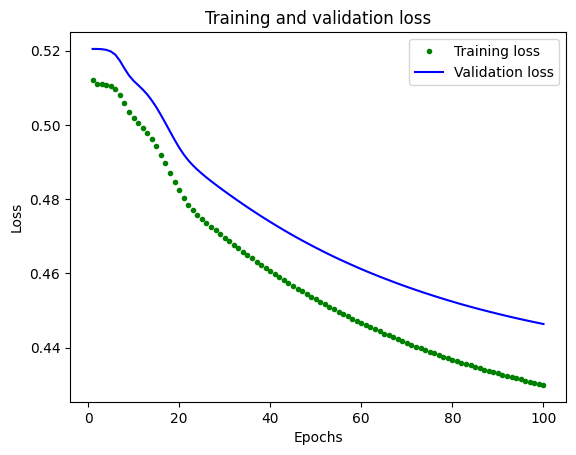

In [160]:
loss = history_1.history['loss']
val_loss = history_1.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'g.', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

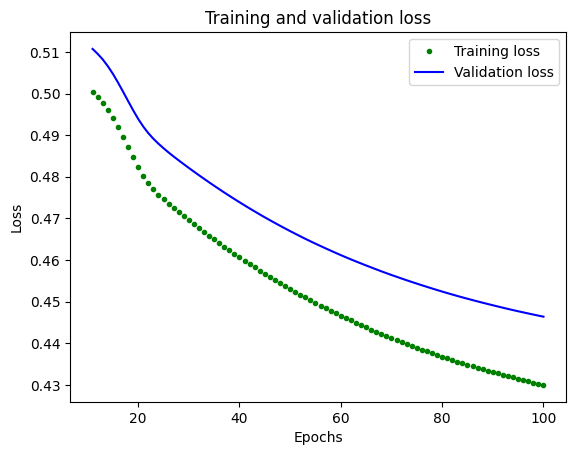

In [161]:
SKIP = 10

plt.plot(epochs[SKIP:], loss[SKIP:], 'g.', label='Training loss')
plt.plot(epochs[SKIP:], val_loss[SKIP:], 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

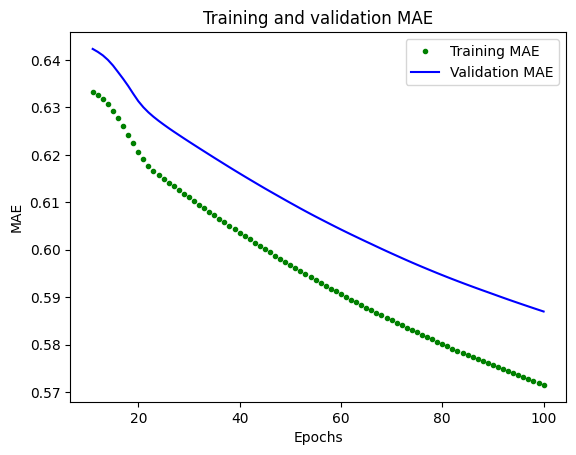

In [162]:
mae = history_1.history['mae']
val_mae = history_1.history['val_mae']

plt.plot(epochs[SKIP:], mae[SKIP:], 'g.', label='Training MAE') 
plt.plot(epochs[SKIP:], val_mae[SKIP:], 'b', label='Validation MAE')
plt.title('Training and validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4698 - mae: 0.5993 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


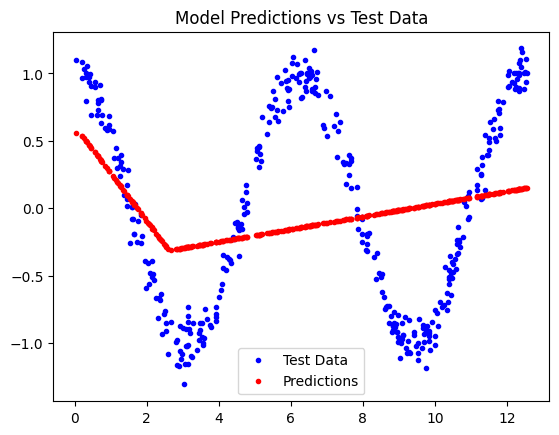

In [163]:
# Calculate and print loss on our test dataset
loss = model_1.evaluate(x_test, y_test)

# use model to make predictions from our test data
predictions = model_1.predict(x_test)
# plot the predictions along with the test data
plt.clf()
plt.title('Model Predictions vs Test Data')
plt.plot(x_test, y_test, 'b.', label='Test Data')
plt.plot(x_test, predictions, 'r.', label='Predictions')
plt.legend()
plt.show()

In [164]:
# Create a new model with more layers
model_2 = tf.keras.Sequential()
model_2.add(layers.Dense(16, activation='relu', input_shape=(1,)))

model_2.add(layers.Dense(16, activation='relu'))
model_2.add(layers.Dense(1))
model_2.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
model_2.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [165]:
# train the new model
history_2 = model_2.fit(x_train, y_train, epochs=500, batch_size=16, validation_data=(x_validate, y_validate))

Epoch 1/500
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5214 - mae: 0.6470 - val_loss: 0.5204 - val_mae: 0.6472
Epoch 2/500
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5184 - mae: 0.6445 - val_loss: 0.5205 - val_mae: 0.6474
Epoch 3/500
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5179 - mae: 0.6442 - val_loss: 0.5205 - val_mae: 0.6475
Epoch 4/500
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5174 - mae: 0.6439 - val_loss: 0.5200 - val_mae: 0.6473
Epoch 5/500
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5142 - mae: 0.6419 - val_loss: 0.5150 - val_mae: 0.6444
Epoch 6/500
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5091 - mae: 0.6386 - val_loss: 0.5105 - val_mae: 0.6416
Epoch 7/500
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5038 - mae: 0.6351 - val_loss: 0.5054 - val_mae: 0.6385
Epoch 8/500
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4979 - mae: 0.6313 - val_loss: 0.4997 - val_mae: 0.6349
Epoch 9/500
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.491

In [166]:
# Convert the model to the TensorFlow Lite format w/o quantisation
converter = tf.lite.TFLiteConverter.from_keras_model(model_2)
tflite_model = converter.convert()

# Save the model to disk
open("model_2.tflite", "wb").write(tflite_model)

# Convert the model to the TensorFlow Lite format w quantisation
converter = tf.lite.TFLiteConverter.from_keras_model(model_2)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
# Define a representative dataset generator function
def representative_data_gen():
    for value in x_test:
        # Each scalar value inside a 2D array that is wrapped in a list
        yield [np.array(value, dtype=np.float32, ndmin =2)]

converter.representative_dataset = representative_data_gen
# convert the model
tflite_model_2 = converter.convert()

# Save the model to disk
open("model_2_quant.tflite", "wb").write(tflite_model_2)

INFO:tensorflow:Assets written to: C:\Users\jonat\AppData\Local\Temp\tmpj1xe9zfz\assets


INFO:tensorflow:Assets written to: C:\Users\jonat\AppData\Local\Temp\tmpj1xe9zfz\assets


Saved artifact at 'C:\Users\jonat\AppData\Local\Temp\tmpj1xe9zfz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor_66')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2040315446672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2040315448784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2040315446096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2040315445328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2040315449360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2040315445520: TensorSpec(shape=(), dtype=tf.resource, name=None)
INFO:tensorflow:Assets written to: C:\Users\jonat\AppData\Local\Temp\tmp7ubrzjf5\assets


INFO:tensorflow:Assets written to: C:\Users\jonat\AppData\Local\Temp\tmp7ubrzjf5\assets


Saved artifact at 'C:\Users\jonat\AppData\Local\Temp\tmp7ubrzjf5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor_66')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2040315446672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2040315448784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2040315446096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2040315445328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2040315449360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2040315445520: TensorSpec(shape=(), dtype=tf.resource, name=None)


c:\Jon\Uni stuff\CE\Embedded-Systems\.venv\Lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


3752

c:\Jon\Uni stuff\CE\Embedded-Systems\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


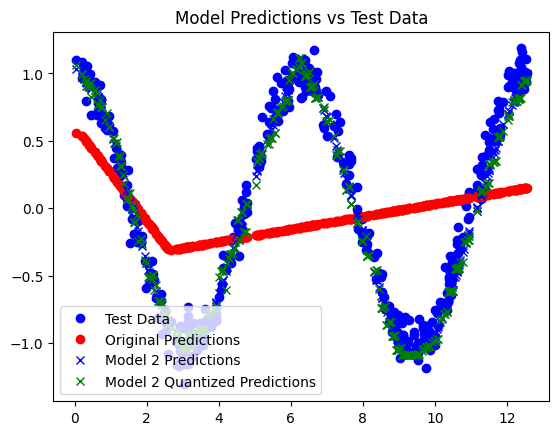

In [167]:
# Instantiate a TFLite interpreter for each model
intpret_model_2 = tf.lite.Interpreter(model_path="model_2.tflite")
intpret_model_2_quant = tf.lite.Interpreter(model_path="model_2_quant.tflite")

# allocate memory for the models
intpret_model_2.allocate_tensors()
intpret_model_2_quant.allocate_tensors()

# Get indexes of input and output tensors for both models
input_index_2 = intpret_model_2.get_input_details()[0]['index']
output_index_2 = intpret_model_2.get_output_details()[0]['index']
input_index_2_quant = intpret_model_2_quant.get_input_details()[0]['index']
output_index_2_quant = intpret_model_2_quant.get_output_details()[0]['index']

# create arrays to hold predictions
model_2_preds = []
model_2_quant_preds = []

for value in x_test:
    # create 2D tensor wrapping the current x value
    x_val_tensor = tf.convert_to_tensor([[value]], dtype=np.float32)
    # write the value to the input tensor
    intpret_model_2.set_tensor(input_index_2, x_val_tensor)
    # run inference
    intpret_model_2.invoke()
    # read the output tensor
    model_2_preds.append(intpret_model_2.get_tensor(output_index_2)[0][0])
    # now do the same for the quantized model
    intpret_model_2_quant.set_tensor(input_index_2_quant, x_val_tensor)
    intpret_model_2_quant.invoke()
    model_2_quant_preds.append(intpret_model_2_quant.get_tensor(output_index_2_quant)[0][0])


# plot the predictions along with the test data
plt.clf()
plt.title('Model Predictions vs Test Data')
plt.plot(x_test, y_test, 'bo', label='Test Data')
plt.plot(x_test, predictions, 'ro', label='Original Predictions')
plt.plot(x_test, model_2_preds, 'bx', label='Model 2 Predictions')
plt.plot(x_test, model_2_quant_preds, 'gx', label='Model 2 Quantized Predictions')
plt.legend()
plt.show()